The goal with this notebook is to test out a different pretrained model, it is just a larger version than EfficientNetV2B0. It will be trained on the A100 for efficiency, also it will implement a smaller image size of 256x256 which the pretrained model is trained on, and also what they have done on the nutrition5K dataset. Additionally will it also implement data augmentation, which includes a small zoom, rotation and mild contrast/brightness changes in the images.

Prerequisits

In [ ]:
!pip install -q huggingface_hub

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Libraries needed

In [ ]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
from huggingface_hub import create_repo, upload_folder

Paths to dataset

In [ ]:
DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")

# Metadata CSV
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_split_metadata.csv")

# Output folder for this model
OUTPUT_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_2_5_efficientnetv2s_rgb_pretrained_augmented")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [ ]:
df = pd.read_csv(METADATA_CSV)

print(df.head())
print(df["split"].value_counts())

           dish_id  total_carb split source_cafe
0  dish_1556575327      10.618  test       cafe1
1  dish_1557861216       0.000  test       cafe1
2  dish_1557862345       0.000  test       cafe1
3  dish_1557862696       3.850  test       cafe1
4  dish_1557862738       0.000  test       cafe1
split
train    2421
test      507
val       334
Name: count, dtype: int64


In [ ]:
df["image_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / d / "overhead" / "rgb.png")
)

df["image_exists"] = df["image_path"].apply(lambda p: Path(p).exists())

print("Missing images:", (~df["image_exists"]).sum())

df = df[df["image_exists"]].copy()

print(df["split"].value_counts())
print(df.head())

Missing images: 0
split
train    2421
test      507
val       334
Name: count, dtype: int64
           dish_id  total_carb split source_cafe  \
0  dish_1556575327      10.618  test       cafe1   
1  dish_1557861216       0.000  test       cafe1   
2  dish_1557862345       0.000  test       cafe1   
3  dish_1557862696       3.850  test       cafe1   
4  dish_1557862738       0.000  test       cafe1   

                                          image_path  image_exists  
0  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
1  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
2  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
3  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  
4  /content/drive/MyDrive/Speciale/dataset/nutrit...          True  


In [ ]:
train_df = df[df["split"] == "train"].copy()
val_df   = df[df["split"] == "val"].copy()
test_df  = df[df["split"] == "test"].copy()

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Train: 2421
Val:   334
Test:  507


Settings

In [ ]:
IMG_HEIGHT = 256
IMG_WIDTH  = 256
BATCH_SIZE = 32
AUTOTUNE   = tf.data.AUTOTUNE
EPOCHS     = 300

Data loading

In [ ]:
def load_image_and_label(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_png(image, channels=3)
    image = tf.image.resize(image, [IMG_HEIGHT, IMG_WIDTH])
    image = tf.cast(image, tf.float32)   # keep in [0,255]
    label = tf.cast(label, tf.float32)
    return image, label


def make_dataset(dataframe, batch_size=8, shuffle=False):
    image_paths = dataframe["image_path"].values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=42)

    ds = ds.map(load_image_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


train_dataset = make_dataset(train_df, batch_size=BATCH_SIZE, shuffle=True)
validation_dataset = make_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_dataset = make_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

Data augmentation

In [ ]:
def mild_brightness_contrast(img):
    img = tf.image.random_brightness(img, max_delta=0.08)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img


data_augmentation = keras.Sequential([
    layers.RandomRotation(factor=0.03),
    layers.RandomZoom(height_factor=(-0.08, 0.08), width_factor=(-0.08, 0.08)),
    layers.RandomTranslation(height_factor=0.03, width_factor=0.03),
    layers.Lambda(
        mild_brightness_contrast,
        output_shape=lambda input_shape: input_shape
    ),
], name="data_augmentation")

Model architecture

In [ ]:
from tensorflow.keras.applications import EfficientNetV2S

base_model = EfficientNetV2S(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)
)

# First stage: freeze pretrained backbone
base_model.trainable = False

inputs = keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3), name="rgb_input")

# Apply augmentation only during training
x = data_augmentation(inputs)

# Forward pass through pretrained backbone
x = base_model(x, training=False)

# Head for regression
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dropout(0.3, name="dropout")(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.2, name="dropout_2")(x)
x = layers.Dense(128, activation="relu", name="dense_128")(x)
outputs = layers.Dense(1, activation="linear", name="carb_output")(x)

model = keras.Model(inputs, outputs, name="efficientnetv2s_rgb_pretrained_carb_regression_model_2_5")
model.summary()

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetv2s_rgb_pretrained_carb_regression_model_2_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 8, 8, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,692,321 (78.93 MB)

 Trainable params: 360,961 (1.38 MB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=150,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=125,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 643ms/step - loss: 480.0371 - mae: 13.6524 - mse: 480.0371
Epoch 1: val_loss improved from None to 186.71802, saving model to /content/drive/MyDrive/Speciale/Models/Model_2_5_efficientnetv2s_rgb_pretrained_augmented/best_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_2_5_efficientnetv2s_rgb_pretrained_augmented/best_model.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 90s 847ms/step - loss: 514.4213 - mae: 11.8854 - mse: 514.4213 - val_loss: 186.7180 - val_mae: 10.5315 - val_mse: 186.7180 - learning_rate: 0.0010
Epoch 2/300
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 394.4774 - mae: 9.2880 - mse: 394.4774
Epoch 2: val_loss did not improve from 186.71802
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 428.6343 - mae: 9.4231 - mse: 428.6343 - val_loss: 197.5876 - val_mae: 11.4069 - val_mse: 197.5876 - learning_rate: 0.0010
Epoch 3/300
75/76 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 148.3566 - mae: 8.3979 - mse: 

Plotting training and validation

In [ ]:
def plot_metrics(history):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, h["loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title("Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    if "mae" in h and "val_mae" in h:
        axes[1].plot(epochs, h["mae"], marker="o", label="Train MAE")
        axes[1].plot(epochs, h["val_mae"], marker="o", label="Val MAE")
        axes[1].set_title("Mean Absolute Error")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, linestyle="--", alpha=0.5)

    if "mse" in h and "val_mse" in h:
        axes[2].plot(epochs, h["mse"], marker="o", label="Train MSE")
        axes[2].plot(epochs, h["val_mse"], marker="o", label="Val MSE")
        axes[2].set_title("Mean Squared Error")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("MSE")
        axes[2].legend()
        axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    best = np.argmin(h["val_loss"])
    print(f"Best val_loss: {h['val_loss'][best]:.4f} at epoch {best + 1}")

    if "val_mae" in h:
        print(f"Val MAE at best epoch: {h['val_mae'][best]:.4f}")
    if "val_mse" in h:
        print(f"Val MSE at best epoch: {h['val_mse'][best]:.4f}")

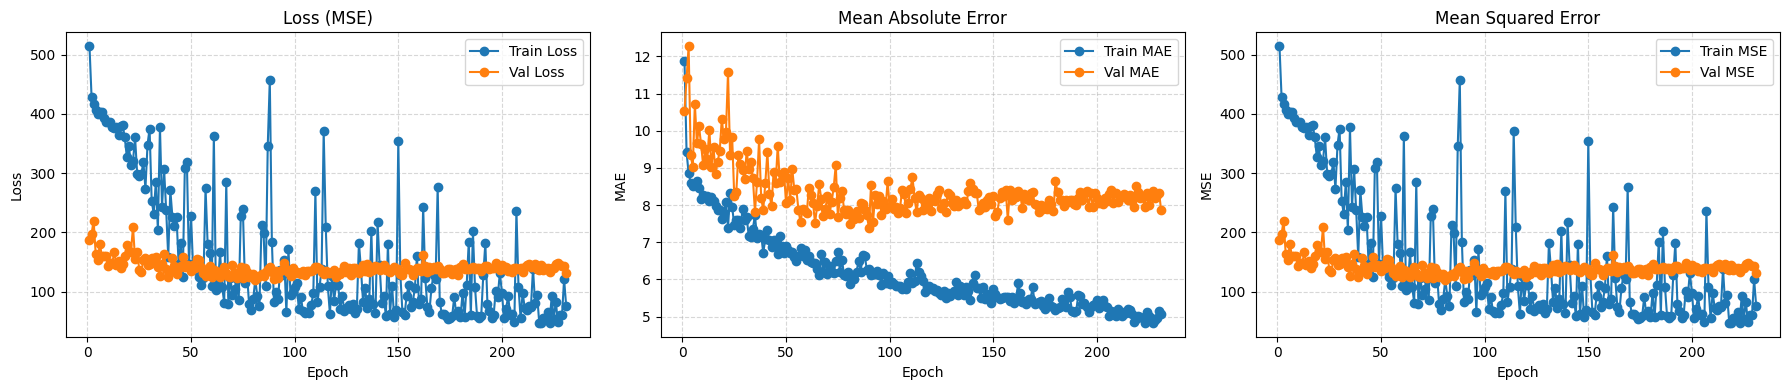

Best val_loss: 119.8757 at epoch 81
Val MAE at best epoch: 7.4992
Val MSE at best epoch: 119.8757


In [ ]:
plot_metrics(history)

Testing model on test dataset

In [ ]:
loaded_model = tf.keras.models.load_model(str(OUTPUT_DIR / "best_model.keras"), compile=False)

In [ ]:
loaded_model_test_results = loaded_model.evaluate(test_dataset, return_dict=True)
print(loaded_model_test_results)

In [ ]:
test_results = model.evaluate(test_dataset, return_dict=True)
print(test_results)

16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 661ms/step - loss: 114.6790 - mae: 7.2698 - mse: 114.6790
{'loss': 114.67904663085938, 'mae': 7.269800186157227, 'mse': 114.67904663085938}


Not the best performance from the model, so a larger part of the pretrained model will be unfrozen and wil be able to be trained.

In [ ]:
base_model.trainable = True

fine_tune_at = len(base_model.layers) - 120

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Freeze BatchNormalization layers for stability
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print("Total layers in base_model:", len(base_model.layers))
print("Fine-tuning from layer index:", fine_tune_at)

trainable_count = np.sum([layer.trainable for layer in base_model.layers])
print("Trainable layers in base_model:", trainable_count)

Total layers in base_model: 513
Fine-tuning from layer index: 393
Trainable layers in base_model: 96


In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)

In [ ]:
stage2_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(OUTPUT_DIR / "best_model_stage2_finetuned.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=50,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=35,
        min_lr=1e-7,
        mode="min",
        verbose=1
    )
]

In [ ]:
EPOCHS_STAGE2 = 100

In [ ]:
history_stage2 = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS_STAGE2,
    callbacks=stage2_callbacks
)

Epoch 1/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 285.5779 - mae: 6.2969 - mse: 285.5779
Epoch 1: val_loss improved from None to 124.45034, saving model to /content/drive/MyDrive/Speciale/Models/Model_2_5_efficientnetv2s_rgb_pretrained_augmented/best_model_stage2_finetuned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_2_5_efficientnetv2s_rgb_pretrained_augmented/best_model_stage2_finetuned.keras
76/76 ━━━━━━━━━━━━━━━━━━━━ 44s 200ms/step - loss: 260.6252 - mae: 6.1724 - mse: 260.6252 - val_loss: 124.4503 - val_mae: 7.5834 - val_mse: 124.4503 - learning_rate: 1.0000e-05
Epoch 2/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 149.2029 - mae: 5.9639 - mse: 149.2029
Epoch 2: val_loss did not improve from 124.45034
76/76 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - loss: 222.3774 - mae: 5.9910 - mse: 222.3774 - val_loss: 127.8639 - val_mae: 7.8480 - val_mse: 127.8639 - learning_rate: 1.0000e-05
Epoch 3/100
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step -

Plotting stage 2

In [ ]:
def plot_metrics(history, title="Training history"):
    h = history.history
    epochs = np.arange(1, len(h["loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(epochs, h["loss"], marker="o", label="Train Loss")
    axes[0].plot(epochs, h["val_loss"], marker="o", label="Val Loss")
    axes[0].set_title(f"{title} - Loss (MSE)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    if "mae" in h and "val_mae" in h:
        axes[1].plot(epochs, h["mae"], marker="o", label="Train MAE")
        axes[1].plot(epochs, h["val_mae"], marker="o", label="Val MAE")
        axes[1].set_title(f"{title} - Mean Absolute Error")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("MAE")
        axes[1].legend()
        axes[1].grid(True, linestyle="--", alpha=0.5)

    if "mse" in h and "val_mse" in h:
        axes[2].plot(epochs, h["mse"], marker="o", label="Train MSE")
        axes[2].plot(epochs, h["val_mse"], marker="o", label="Val MSE")
        axes[2].set_title(f"{title} - Mean Squared Error")
        axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("MSE")
        axes[2].legend()
        axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

    best = np.argmin(h["val_loss"])
    print(f"Best val_loss: {h['val_loss'][best]:.4f} at epoch {best + 1}")
    if "val_mae" in h:
        print(f"Val MAE at best epoch: {h['val_mae'][best]:.4f}")
    if "val_mse" in h:
        print(f"Val MSE at best epoch: {h['val_mse'][best]:.4f}")

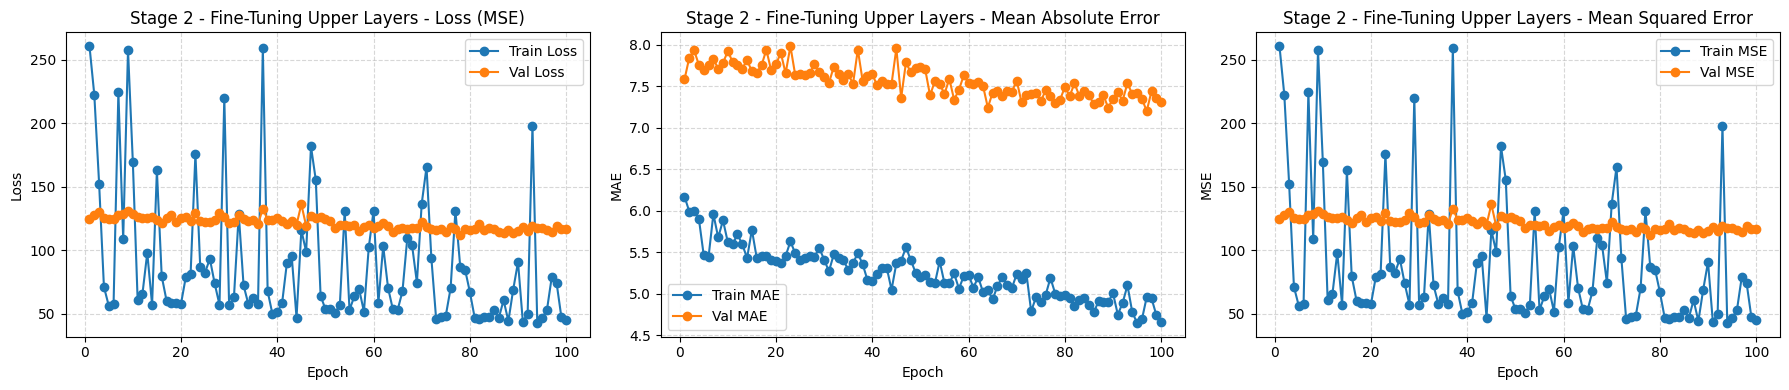

Best val_loss: 112.2504 at epoch 78
Val MAE at best epoch: 7.2994
Val MSE at best epoch: 112.2504


In [ ]:
plot_metrics(history_stage2, title="Stage 2 - Fine-Tuning Upper Layers")

Testing on test set

In [ ]:
test_results = model.evaluate(test_dataset, return_dict=True)
print(test_results)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - loss: 106.3270 - mae: 6.9503 - mse: 106.3270
{'loss': 106.32699584960938, 'mae': 6.950257301330566, 'mse': 106.32699584960938}
